# Machine Learning: predicción a 24 horas — PM2.5 Pekín

Entrenamiento con `skforecast.ForecasterRecursive`, validación temporal en 2013 y test en 2014.
Se evalúan todas las horas con objetivo medido. Los lags mínimos de 24 horas permiten
predecir el horizonte 24 en un solo lote: ninguna entrada depende de predicciones intermedias.
Skforecast construye las matrices y ajusta los modelos; se usa su estimador ajustado para el lote.

**CSV de entrenamiento:** `data/processed/beijing_data_huecos_24h.csv`.
**CSV auxiliar:** `data/processed/beijing_data_preparado.csv`, solo para `pm2.5_imputado`.
La búsqueda adicional de picos está desactivada por defecto.


In [1]:
from pathlib import Path
from time import perf_counter
from threadpoolctl import threadpool_limits

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skforecast.recursive import ForecasterRecursive

INICIO = perf_counter()
EJECUTAR_PICOS = False
H = 24
UMBRAL = 150
SEMILLA = 42
RAIZ = Path('..') if Path('../data').exists() else Path('.')
print('skforecast:', __import__('skforecast').__version__)


skforecast: 0.25.0


c:\Users\martin\Documents\uc3m - Applied AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning
)

## 1. Datos

Se lee `beijing_data_huecos_24h.csv`, con PM2.5, calendario y meteorología desplazada 24 horas.
Se conserva el calendario horario. El CSV auxiliar preparado permite identificar los objetivos
imputados y excluirlos de las métricas y del entrenamiento mediante pesos.


In [3]:
df = pd.read_csv(RAIZ / 'data/processed/beijing_data_huecos_24h.csv',
                 index_col='datetime', parse_dates=True)
df = df.sort_index().asfreq('h')

print('Horas:', len(df))
print('Huecos en PM2.5:', df['pm2.5'].isna().sum())
df.head()

Horas: 43794
Huecos en PM2.5: 1463


,pm2.5,cal_sen_hora,cal_cos_hora,cal_sen_dia,cal_cos_dia,cal_sen_mes,cal_cos_mes,DEWP_obs_24,TEMP_obs_24,PRES_obs_24,Iws_obs_24,Is_obs_24,Ir_obs_24,viento_NE_obs_24,viento_NW_obs_24,viento_SE_obs_24,TEMP_trend_24_30,PRES_trend_24_30
datetime,,,,,,,,,,,,,,,,,,
2010-01-02 06:00:00,105.0,1.000000,6.123234e-17,-0.974928,-0.222521,0.0,1.0,-19.0,-9.0,1017.0,19.23,0.0,0.0,0,1,0,2.0,-4.0
2010-01-02 07:00:00,124.0,0.965926,-2.588190e-01,-0.974928,-0.222521,0.0,1.0,-19.0,-9.0,1017.0,21.02,0.0,0.0,0,1,0,3.0,-3.0
2010-01-02 08:00:00,120.0,0.866025,-5.000000e-01,-0.974928,-0.222521,0.0,1.0,-19.0,-9.0,1017.0,24.15,0.0,0.0,0,1,0,2.0,-2.0
2010-01-02 09:00:00,132.0,0.707107,-7.071068e-01,-0.974928,-0.222521,0.0,1.0,-20.0,-8.0,1017.0,27.28,0.0,0.0,0,1,0,6.0,-2.0
2010-01-02 10:00:00,140.0,0.500000,-8.660254e-01,-0.974928,-0.222521,0.0,1.0,-19.0,-7.0,1017.0,31.30,0.0,0.0,0,1,0,5.0,-1.0


## 2. Variables predictoras

Las exógenas están alineadas con la hora objetivo: el calendario es conocido y la
meteorología está desplazada 24 horas. `ForecasterRecursive` construye los lags.
Como todos son mayores o iguales al horizonte, el paso 24 solo depende del historial
observado hasta el origen. Se predice ese paso por lotes con el estimador entrenado.
La marca de imputación solo controla los pesos, no se usa como predictor.


In [4]:
# Skforecast recibe la serie completa y construye los retardos internamente.
# La marca se recupera del CSV preparado, que es el único que la conserva.
df_trazabilidad = pd.read_csv(
    RAIZ / 'data/processed/beijing_data_preparado.csv',
    index_col='datetime', parse_dates=True
).sort_index().asfreq('h')

marca = df_trazabilidad['pm2.5_imputado'].reindex(df.index)
assert marca.notna().all(), 'Falta trazabilidad para algunas horas'
assert marca.isin([True, False, 0, 1]).all(), 'Marca de imputación no válida'
pm25_imputado = marca.astype(bool)

# Los huecos largos se completan solo para mantener la continuidad requerida por
# ForecasterRecursive; se marcan como imputados y no cuentan en el entrenamiento.
y_sf = df['pm2.5'].ffill()
assert y_sf.notna().all(), 'La serie empieza con huecos: recortar antes de entrenar'
pm25_imputado = pm25_imputado | df['pm2.5'].isna()
exog_sf = df.drop(columns='pm2.5').copy()

print('Observaciones para skforecast:', len(y_sf))
print('Valores imputados o completados:', int(pm25_imputado.sum()))
print('Exógenas:', exog_sf.shape[1])

assert exog_sf.notna().all().all(), 'Hay huecos en las exógenas'
assert np.isfinite(exog_sf.to_numpy()).all()


Observaciones para skforecast: 43794
Valores imputados o completados: 2043
Exógenas: 17


Los lags `[24, 25, 26, 27, 30, 36, 48]` respecto al objetivo corresponden
a la observación actual y a hace 1, 2, 3, 6, 12 y 24 horas respecto al origen.
No se añaden medias móviles. Todas las entradas están disponibles al emitir el pronóstico.
Los huecos de PM2.5 se completan hacia delante; las filas afectadas reciben peso cero.


In [5]:
# ForecasterRecursive construira estos retardos en cada fold.
lags_skforecast = [24, 25, 26, 27, 30, 36, 48]
filas_afectadas = pm25_imputado.copy()
for retardo in lags_skforecast:
    filas_afectadas = filas_afectadas | pm25_imputado.shift(retardo, fill_value=False)
print('Lags de skforecast:', lags_skforecast)
print('Ejemplos afectados por imputacion:', int(filas_afectadas.sum()))


Lags de skforecast: [24, 25, 26, 27, 30, 36, 48]
Ejemplos afectados por imputacion: 4917


## 3. Particiones temporales

Se hace uso de las mismas particiones temporales que en los modelos baseline.

Se entrena con objetivos ya observados hasta el corte. La validación empieza
con predicciones emitidas en el periodo siguiente. Por eso su primera hora
objetivo es el inicio de ese periodo más 24 horas, igual que en 05_1.

| Ronda | Entrenamiento hasta | Orígenes de validación desde | Objetivos hasta |
|---|---|---|---|
| 1 | Diciembre 2012 | Enero 2013 | Abril 2013 |
| 2 | Abril 2013 | Mayo 2013 | Agosto 2013 |
| 3 | Agosto 2013 | Septiembre 2013 | Diciembre 2013 |

El modelo se ajusta una vez por ronda. Al avanzar las horas cambian las entradas
con las nuevas observaciones disponibles, pero no se reentrena cada hora.


In [6]:
pliegues = [
    ('2012-12-31 23:00:00', '2013-01-01 00:00:00', '2013-04-30 23:00:00'),
    ('2013-04-30 23:00:00', '2013-05-01 00:00:00', '2013-08-31 23:00:00'),
    ('2013-08-31 23:00:00', '2013-09-01 00:00:00', '2013-12-31 23:00:00'),
]
for fin_train, inicio_valid, fin_valid in pliegues:
    primer_objetivo = pd.Timestamp(inicio_valid) + pd.Timedelta(hours=int(H))
    y_train_fold = y_sf.loc[:fin_train]
    indice_valid = y_sf.loc[primer_objetivo:fin_valid].index
    assert y_train_fold.index.max() < indice_valid.min() - pd.Timedelta(hours=int(H))
    print(f'Train: {len(y_train_fold)} | Validacion: {len(indice_valid)} | Primer objetivo: {indice_valid.min()}')


Train: 26274 | Validacion: 2856 | Primer objetivo: 2013-01-02 00:00:00
Train: 29154 | Validacion: 2928 | Primer objetivo: 2013-05-02 00:00:00
Train: 32106 | Validacion: 2904 | Primer objetivo: 2013-09-02 00:00:00


## 4. Métricas y validación

Se selecciona por RMSE medio en las tres rondas, como en 05_1. El MAE expresa
el error absoluto medio. El RMSE da más peso a errores grandes.
Todas las predicciones se limitan a cero como mínimo, porque una concentración
negativa no tiene sentido; se aplica la misma regla en validación y test.


In [7]:
class StandardizedRidge(RegressorMixin, BaseEstimator):
    def __init__(self, alpha=1):
        self.alpha = alpha

    def fit(self, X, y, sample_weight=None):
        self.scaler_ = StandardScaler().fit(X, sample_weight=sample_weight)
        self.model_ = Ridge(alpha=self.alpha)
        self.model_.fit(
            self.scaler_.transform(X),
            y,
            sample_weight=sample_weight
        )
        return self

    def predict(self, X):
        return self.model_.predict(self.scaler_.transform(X))


def rmse(real, predicho):
    return np.sqrt(mean_squared_error(real, predicho))


def crear_forecaster(modelo):
    def weight_func(index):
        afectados = filas_afectadas.reindex(index).fillna(True)
        return pd.Series(
            (~afectados).astype(float).to_numpy(),
            index=index
        )

    return ForecasterRecursive(
        estimator=clone(modelo),
        lags=lags_skforecast,
        weight_func=weight_func
    )


def pronosticar_24h(forecaster, indices_objetivo, columnas):
    # Exacto para esta configuración: t-lag <= t-H para todos los lags.
    # No es válido si se añaden lags menores que H o transformaciones del objetivo.
    if min(forecaster.lags) < H:
        raise ValueError('La predicción por lotes requiere todos los lags >= H')
    X, _ = forecaster.create_train_X_y(y=y_sf, exog=exog_sf[columnas])
    X = X.loc[indices_objetivo]
    with threadpool_limits(limits=2):
        pred = forecaster.estimator.predict(X.to_numpy())
    return pd.Series(pred, index=indices_objetivo)


def validar(modelo, columnas=None):
    columnas = (
        list(exog_sf.columns)
        if columnas is None
        else list(columnas)
    )

    resultados = []

    for ronda, (fin_train, inicio_valid, fin_valid) in enumerate(
        pliegues,
        start=1
    ):
        primer_objetivo = (
            pd.Timestamp(inicio_valid)
            + pd.Timedelta(hours=int(H))
        )

        # Evaluación de todas las horas
        indice_valid = (
            y_sf.loc[primer_objetivo:fin_valid]
            .index
        )

        y_train = y_sf.loc[:fin_train]

        forecaster = crear_forecaster(modelo)

        with threadpool_limits(limits=2):
            forecaster.fit(y=y_train, exog=exog_sf.loc[y_train.index, columnas])

        pred = pronosticar_24h(
            forecaster,
            indice_valid,
            columnas
        ).clip(lower=0)

        validos = (
            (~pm25_imputado.loc[indice_valid])
            & df['pm2.5'].loc[indice_valid].notna()
        )

        objetivo = df['pm2.5'].loc[indice_valid][validos]
        pred = pred[validos]

        naive = y_sf.shift(H).loc[pred.index]

        resultados.append({
            'ronda': ronda,
            'n': len(objetivo),
            'RMSE': rmse(objetivo, pred),
            'MAE': mean_absolute_error(objetivo, pred),
            'RMSE_naive': rmse(objetivo, naive)
        })

    return pd.DataFrame(resultados)


## 5. Qué aporta la meteorología

Se compara Ridge con calendario frente a todas las exógenas meteorológicas disponibles.
En este CSV el antiguo grupo B coincidía con C; se elimina esa repetición.
Ambos casos usan los mismos lags de PM2.5 y las mismas horas de validación.


In [8]:
grupos = {
    'Calendario': [c for c in exog_sf if c.startswith('cal_')],
    'Calendario y meteorología': list(exog_sf.columns),
}
aporte_variables = []
for nombre, columnas in grupos.items():
    resultado = validar(StandardizedRidge(alpha=100), columnas)
    aporte_variables.append({'variables': nombre, 'RMSE': resultado['RMSE'].mean(),
                            'MAE': resultado['MAE'].mean()})
aporte_variables = pd.DataFrame(aporte_variables).set_index('variables')
display(aporte_variables.round(3))


,RMSE,MAE
variables,,
Calendario,87.688,65.671
Calendario y meteorología,85.416,62.730


## 6. Tres algoritmos

**Ridge** combina las variables con pesos y penaliza pesos grandes. `alpha`
controla esa penalización. El escalado se aprende dentro de cada entrenamiento.

**Random Forest** promedia árboles que aprenden reglas distintas. Se prueban
tres tamaños de árbol. `min_samples_leaf` evita reglas sostenidas en muy pocos
ejemplos. Se mantienen 100 árboles para que la comparación sea manejable.

**Gradient Boosting** construye árboles sucesivos para reducir el error.
Se prueban tres tamaños, manteniendo el ritmo de aprendizaje y 200 iteraciones.
Se desactiva la parada automática para evitar una validación interna aleatoria.

La búsqueda es pequeña: tres configuraciones por algoritmo. Los tres reciben
todas las variables. Se elige la mejor configuración de cada algoritmo con 2013.


In [9]:
candidatos = {
    'Ridge': {
        'alpha=1': StandardizedRidge(alpha=1),
        'alpha=100': StandardizedRidge(alpha=100),
        'alpha=1000': StandardizedRidge(alpha=1000),
    },
    'Random Forest': {
        'profundidad=8': RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=10,
            random_state=SEMILLA,
            n_jobs=2
        ),
        'profundidad=12': RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=10,
            random_state=SEMILLA,
            n_jobs=2
        ),
        'profundidad=16': RandomForestRegressor(
            n_estimators=100,
            max_depth=16,
            min_samples_leaf=10,
            random_state=SEMILLA,
            n_jobs=2
        ),
    },
    'Gradient Boosting': {
        'hojas=7': HistGradientBoostingRegressor(
            max_leaf_nodes=7,
            learning_rate=0.05,
            max_iter=200,
            min_samples_leaf=30,
            early_stopping=False,
            random_state=SEMILLA
        ),
        'hojas=15': HistGradientBoostingRegressor(
            max_leaf_nodes=15,
            learning_rate=0.05,
            max_iter=200,
            min_samples_leaf=30,
            early_stopping=False,
            random_state=SEMILLA
        ),
        'hojas=31': HistGradientBoostingRegressor(
            max_leaf_nodes=31,
            learning_rate=0.05,
            max_iter=200,
            min_samples_leaf=30,
            early_stopping=False,
            random_state=SEMILLA
        ),
    }
}

resultados_cv = []

for nombre, configuraciones in candidatos.items():
    for configuracion, modelo in configuraciones.items():
        inicio_modelo = perf_counter()
        resultado = validar(modelo)

        resultado['modelo'] = nombre
        resultado['configuracion'] = configuracion

        resultados_cv.append(resultado)

        print(
            f'{nombre} | {configuracion} | '
            f'RMSE: {resultado["RMSE"].mean():.3f} | {perf_counter() - inicio_modelo:.1f} s'
        )

resultados_cv = pd.concat(
    resultados_cv,
    ignore_index=True
)

resumen_cv = (
    resultados_cv
    .groupby(['modelo', 'configuracion'])
    .agg(
        RMSE_medio=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAE_medio=('MAE', 'mean'),
        RMSE_naive=('RMSE_naive', 'mean'),
    )
    .reset_index()
    .sort_values('RMSE_medio')
)

mejores = resumen_cv.drop_duplicates('modelo').copy()
ganador_validacion = mejores.iloc[0]['modelo']

display(resumen_cv.round(3))
print('Modelo elegido en validación:', ganador_validacion)


Ridge | alpha=1 | RMSE: 85.410 | 0.2 s
Ridge | alpha=100 | RMSE: 85.416 | 0.2 s
Ridge | alpha=1000 | RMSE: 85.489 | 0.2 s
Random Forest | profundidad=8 | RMSE: 87.508 | 15.2 s
Random Forest | profundidad=12 | RMSE: 88.292 | 20.6 s
Random Forest | profundidad=16 | RMSE: 88.508 | 29.2 s
Gradient Boosting | hojas=7 | RMSE: 84.854 | 4.9 s
Gradient Boosting | hojas=15 | RMSE: 85.044 | 5.9 s
Gradient Boosting | hojas=31 | RMSE: 85.879 | 6.5 s


,modelo,configuracion,RMSE_medio,RMSE_std,MAE_medio,RMSE_naive
2,Gradient Boosting,hojas=7,84.854,30.763,62.553,106.308
0,Gradient Boosting,hojas=15,85.044,30.229,62.580,106.308
6,Ridge,alpha=1,85.410,30.957,62.707,106.308
7,Ridge,alpha=100,85.416,30.973,62.730,106.308
8,Ridge,alpha=1000,85.489,31.106,62.926,106.308
1,Gradient Boosting,hojas=31,85.879,30.421,63.226,106.308
5,Random Forest,profundidad=8,87.508,30.481,64.997,106.308
3,Random Forest,profundidad=12,88.292,30.529,65.377,106.308
4,Random Forest,profundidad=16,88.508,30.485,65.477,106.308


Modelo elegido en validación: Gradient Boosting


## 7. Reentrenamiento y test de 2014

Se ajusta la configuración elegida de cada algoritmo con 2010–2013.
Cada objetivo del test se predice usando únicamente entradas disponibles 24 horas antes.
Las filas se calculan juntas por eficiencia; el modelo permanece fijo durante el test.
El test informa resultados y no cambia configuraciones. El análisis exploratorio previo
ya examinó 2014, limitación que debe reconocerse.


In [10]:
y_train_final = y_sf.loc[:'2013-12-31 23:00:00']
exog_train_final = exog_sf.loc[y_train_final.index]
primer_objetivo_test = pd.Timestamp('2014-01-01') + pd.Timedelta(hours=H)
indice_test = y_sf.loc[primer_objetivo_test:'2014-12-31 23:00:00'].index

predicciones = pd.DataFrame(index=indice_test)
predicciones['real'] = df['pm2.5'].loc[indice_test]
predicciones['naive'] = y_sf.shift(H).loc[indice_test]
modelos_finales = {}
for _, fila in mejores.iterrows():
    nombre = fila['modelo']
    modelo = candidatos[nombre][fila['configuracion']]
    forecaster = crear_forecaster(modelo)
    with threadpool_limits(limits=2):
        forecaster.fit(y=y_train_final, exog=exog_train_final)
    pred = pronosticar_24h(
        forecaster,
        indice_test,
        list(exog_sf.columns),
    ).clip(lower=0)
    modelos_finales[nombre] = forecaster
    predicciones[nombre] = pred

# El test solo informa sobre objetivos que eran mediciones reales.
predicciones = predicciones.loc[~pm25_imputado.loc[predicciones.index]]
y_test = predicciones['real']
print('Horas reales evaluadas por todos los modelos:', len(predicciones))
predicciones.head()


Horas reales evaluadas por todos los modelos: 8637


,real,naive,Gradient Boosting,Ridge,Random Forest
datetime,,,,,
2014-01-02 00:00:00,144.0,24.0,37.042027,41.202309,44.166313
2014-01-02 01:00:00,170.0,53.0,58.566225,51.089882,66.431318
2014-01-02 02:00:00,174.0,65.0,65.818569,56.902513,70.706885
2014-01-02 03:00:00,174.0,70.0,69.483779,58.687310,70.127754
2014-01-02 04:00:00,172.0,79.0,91.948279,92.550693,95.995639


Se calculan errores globales y en horas con PM2.5 > 150, como en 05_1.
El skill es la reducción relativa del error frente a persistencia: positivo mejora;
negativo empeora. MAPE se conserva para comparar, pero puede crecer mucho con
concentraciones cercanas a cero y no se utiliza para elegir el modelo.

Recall y precisión se calculan sobre todas las horas del test: así se cuentan
también las falsas alarmas. Evalúan superaciones horarias, no episodios completos.


In [11]:
def calcular_metricas(real, predicho, naive):
    filas = []
    for nombre, mascara in {'global': real.notna(), f'> {UMBRAL}': real > UMBRAL}.items():
        yt, yp, yn = real[mascara], predicho[mascara], naive[mascara]
        if len(yt) == 0:
            continue
        no_cero = yt != 0
        error_rmse = rmse(yt, yp)
        error_mae = mean_absolute_error(yt, yp)
        base_rmse = rmse(yt, yn)
        base_mae = mean_absolute_error(yt, yn)
        filas.append({
            'subconjunto': nombre, 'n': len(yt),
            'RMSE': error_rmse, 'MAE': error_mae,
            'MAPE': (abs((yt[no_cero] - yp[no_cero]) / yt[no_cero])).mean() * 100,
            'skill_RMSE': 1 - error_rmse / base_rmse if base_rmse else np.nan,
            'skill_MAE': 1 - error_mae / base_mae if base_mae else np.nan,
        })
    return pd.DataFrame(filas)


metricas = []
alertas = []
for nombre in predicciones.columns.drop('real'):
    pred = predicciones[nombre]
    resultado = calcular_metricas(y_test, pred, predicciones['naive'])
    resultado['modelo'] = nombre
    metricas.append(resultado)

    real_alta, pred_alta = y_test > UMBRAL, pred > UMBRAL
    vp = (real_alta & pred_alta).sum()
    fp = (~real_alta & pred_alta).sum()
    fn = (real_alta & ~pred_alta).sum()
    alertas.append({
        'modelo': nombre,
        'recall': vp / (vp + fn) if vp + fn else np.nan,
        'precision': vp / (vp + fp) if vp + fp else np.nan,
        'F1': 2 * vp / (2 * vp + fp + fn) if 2 * vp + fp + fn else np.nan,
        'falsas_alarmas': fp, 'horas_altas_no_detectadas': fn,
    })

metricas = pd.concat(metricas).set_index(['subconjunto', 'modelo']).sort_index()
alertas = pd.DataFrame(alertas).set_index('modelo')
display(metricas.round(3))
display(alertas.round(3))


n     RMSE      MAE     MAPE  skill_RMSE  \
subconjunto modelo                                                           
> 150       Gradient Boosting  1737  134.907  112.721   42.660      -0.022   
            Random Forest      1737  138.584  116.132   43.907      -0.050   
            Ridge              1737  139.352  117.332   44.322      -0.056   
            naive              1737  131.965  107.978   45.133       0.000   
global      Gradient Boosting  8637   81.920   59.917  208.575       0.178   
            Random Forest      8637   84.005   61.058  209.746       0.157   
            Ridge              8637   82.606   61.077  209.138       0.171   
            naive              8637   99.624   67.789  215.175       0.000   

                               skill_MAE  
subconjunto modelo                        
> 150       Gradient Boosting     -0.044  
            Random Forest         -0.076  
            Ridge                 -0.087  
            naive                  0.000  
global      Gradient Boosting      0.116  
            Random Forest          0.099  
            Ridge                  0.099  
            naive                  0.000

,recall,precision,F1,falsas_alarmas,horas_altas_no_detectadas
modelo,,,,,
naive,0.454,0.452,0.453,957,949
Gradient Boosting,0.348,0.578,0.435,442,1132
Ridge,0.297,0.585,0.394,366,1221
Random Forest,0.309,0.554,0.397,432,1200


## 7.1 Referencia histórica de 05_1

Las cifras históricas de SARIMA usan otra selección de horas, por lo que no permiten
una comparación directa. La comparación controlada es con persistencia sobre las mismas
horas en `metricas`. Esta tabla solo conserva la referencia histórica, no interviene en la selección.


In [12]:
comparacion_baselines = pd.DataFrame([
    {'fuente': '05_1', 'modelo': 'SARIMA', 'subconjunto': 'global',
     'RMSE': 85.378, 'MAE': 62.444, 'recall': np.nan, 'F1': np.nan},
    {'fuente': '05_1', 'modelo': 'SARIMA', 'subconjunto': '> 150',
     'RMSE': 157.032, 'MAE': 135.862, 'recall': 0.170, 'F1': 0.267},
    {'fuente': '05_2', 'modelo': 'Ridge', 'subconjunto': 'global',
     'RMSE': metricas.loc[('global', 'Ridge'), 'RMSE'],
     'MAE': metricas.loc[('global', 'Ridge'), 'MAE'],
     'recall': alertas.loc['Ridge', 'recall'], 'F1': alertas.loc['Ridge', 'F1']},
    {'fuente': '05_2', 'modelo': 'Gradient Boosting', 'subconjunto': 'global',
     'RMSE': metricas.loc[('global', 'Gradient Boosting'), 'RMSE'],
     'MAE': metricas.loc[('global', 'Gradient Boosting'), 'MAE'],
     'recall': alertas.loc['Gradient Boosting', 'recall'],
     'F1': alertas.loc['Gradient Boosting', 'F1']},
    {'fuente': '05_2', 'modelo': 'Ridge', 'subconjunto': '> 150',
     'RMSE': metricas.loc[(f'> {UMBRAL}', 'Ridge'), 'RMSE'],
     'MAE': metricas.loc[(f'> {UMBRAL}', 'Ridge'), 'MAE'],
     'recall': alertas.loc['Ridge', 'recall'], 'F1': alertas.loc['Ridge', 'F1']},
    {'fuente': '05_2', 'modelo': 'Gradient Boosting', 'subconjunto': '> 150',
     'RMSE': metricas.loc[(f'> {UMBRAL}', 'Gradient Boosting'), 'RMSE'],
     'MAE': metricas.loc[(f'> {UMBRAL}', 'Gradient Boosting'), 'MAE'],
     'recall': alertas.loc['Gradient Boosting', 'recall'],
     'F1': alertas.loc['Gradient Boosting', 'F1']},
])
comparacion_baselines.round(3)


,fuente,modelo,subconjunto,RMSE,MAE,recall,F1
0,05_1,SARIMA,global,85.378,62.444,NaN,NaN
1,05_1,SARIMA,> 150,157.032,135.862,0.170,0.267
2,05_2,Ridge,global,82.606,61.077,0.297,0.394
3,05_2,Gradient Boosting,global,81.920,59.917,0.348,0.435
4,05_2,Ridge,> 150,139.352,117.332,0.297,0.394
5,05_2,Gradient Boosting,> 150,134.907,112.721,0.348,0.435


## 7.2 Experimento opcional de picos

Desactivado en la ejecución normal. Para ejecutarlo, cambiar `EJECUTAR_PICOS = True`
al principio y volver a ejecutar todo. Añade 18 ajustes y un ajuste final.
Selecciona pesos con 2013 y evalúa en 2014; no modifica el ganador global.


In [13]:
if EJECUTAR_PICOS:
    def crear_forecaster_picos(modelo, multiplicador_picos):
        def weight_func_picos(index):
            afectados = filas_afectadas.reindex(index).fillna(True)
            objetivos_reales = df['pm2.5'].reindex(index).notna()
            objetivos_altos = df['pm2.5'].reindex(index) > UMBRAL
            pesos = ((~afectados) & objetivos_reales).astype(float)
            pesos *= np.where(objetivos_altos, multiplicador_picos, 1)
            return pesos
    
        return ForecasterRecursive(
            estimator=clone(modelo),
            lags=lags_skforecast,
            weight_func=weight_func_picos,
        )
    
    
    def validar_picos(modelo, multiplicador_picos):
        filas = []
        for ronda, (fin_train, inicio_valid, fin_valid) in enumerate(pliegues, start=1):
            primer_objetivo = pd.Timestamp(inicio_valid) + pd.Timedelta(hours=H)
            indice_valid = y_sf.loc[primer_objetivo:fin_valid].index
            y_train = y_sf.loc[:fin_train]
            forecaster = crear_forecaster_picos(modelo, multiplicador_picos)
            forecaster.fit(y=y_train, exog=exog_sf.loc[y_train.index])
            pred = pronosticar_24h(
                forecaster,
                indice_valid,
                list(exog_sf.columns),
            ).clip(lower=0)
    
            validos = (~pm25_imputado.loc[indice_valid]) & df['pm2.5'].loc[indice_valid].notna()
            real = df['pm2.5'].loc[indice_valid][validos]
            pred = pred[validos]
            alta_real = real > UMBRAL
            alta_pred = pred > UMBRAL
            vp = (alta_real & alta_pred).sum()
            fp = (~alta_real & alta_pred).sum()
            fn = (alta_real & ~alta_pred).sum()
            precision = vp / (vp + fp) if vp + fp else np.nan
            recall = vp / (vp + fn) if vp + fn else np.nan
            f1 = 2 * vp / (2 * vp + fp + fn) if 2 * vp + fp + fn else 0.0
            filas.append({
                'ronda': ronda,
                'n': len(real),
                'RMSE': rmse(real, pred),
                'F1_picos': f1,
                'recall_picos': recall,
                'precision_picos': precision,
            })
        return pd.DataFrame(filas)
    
    candidatos_picos = {
        'Ridge': candidatos['Ridge']['alpha=1000'],
        'Gradient Boosting': candidatos['Gradient Boosting']['hojas=7'],
    }
    resultados_picos = []
    for nombre, modelo in candidatos_picos.items():
        for multiplicador in [1, 3, 5]:
            resultado = validar_picos(modelo, multiplicador)
            resultados_picos.append({
                'modelo': nombre,
                'multiplicador_picos': multiplicador,
                'RMSE_medio': resultado['RMSE'].mean(),
                'F1_picos_medio': resultado['F1_picos'].mean(),
                'recall_picos_medio': resultado['recall_picos'].mean(),
                'precision_picos_media': resultado['precision_picos'].mean(),
            })
    
    resumen_picos = pd.DataFrame(resultados_picos).sort_values(
        ['F1_picos_medio', 'recall_picos_medio'], ascending=False
    )
    display(resumen_picos.round(3))
    configuracion_picos = resumen_picos.iloc[0]
    print('Configuración seleccionada para picos:', configuracion_picos.to_dict())
    
else:
    print('Experimento de picos desactivado')


Experimento de picos desactivado


In [14]:
if EJECUTAR_PICOS:
    modelo_picos = candidatos_picos[configuracion_picos['modelo']]
    forecaster_picos_final = crear_forecaster_picos(
        modelo_picos,
        int(configuracion_picos['multiplicador_picos']),
    )
    forecaster_picos_final.fit(y=y_train_final, exog=exog_train_final)
    pred_picos_test = pronosticar_24h(
        forecaster_picos_final,
        indice_test,
        list(exog_sf.columns),
    ).clip(lower=0)
    
    pred_picos_test = pred_picos_test.loc[~pm25_imputado.loc[pred_picos_test.index]]
    real_picos_test = df['pm2.5'].loc[pred_picos_test.index]
    real_alta = real_picos_test > UMBRAL
    pred_alta = pred_picos_test > UMBRAL
    vp = (real_alta & pred_alta).sum()
    fp = (~real_alta & pred_alta).sum()
    fn = (real_alta & ~pred_alta).sum()
    precision = vp / (vp + fp) if vp + fp else np.nan
    recall = vp / (vp + fn) if vp + fn else np.nan
    f1 = 2 * vp / (2 * vp + fp + fn) if 2 * vp + fp + fn else 0.0
    
    resultado_picos_test = pd.DataFrame([{
        'modelo': configuracion_picos['modelo'],
        'multiplicador_picos': configuracion_picos['multiplicador_picos'],
        'RMSE_global': rmse(real_picos_test, pred_picos_test),
        'MAE_global': mean_absolute_error(real_picos_test, pred_picos_test),
        'recall_picos': recall,
        'precision_picos': precision,
        'F1_picos': f1,
        'falsas_alarmas': fp,
        'horas_altas_no_detectadas': fn,
    }])
    resultado_picos_test.round(3)
    
else:
    print('Experimento de picos desactivado')


Experimento de picos desactivado


## 8. Dónde fallan

Se muestran los errores por mes y dos ventanas fijadas de antemano, una de enero
y otra de julio. Las gráficas se usan para describir el resultado, no para cambiar
el modelo después de ver el test. Los huecos se mantienen al dibujar la serie.


,naive,Gradient Boosting,Ridge,Random Forest
mes,,,,
1,110.95,82.10,81.04,84.43
2,89.53,97.46,95.16,98.23
3,81.71,72.24,72.82,73.11
4,51.01,42.64,46.29,44.80
5,42.86,35.38,38.30,36.60
6,41.71,42.35,41.36,42.05
7,45.30,44.23,43.62,43.14
8,38.96,39.73,37.83,38.92
9,45.76,39.57,42.64,41.34


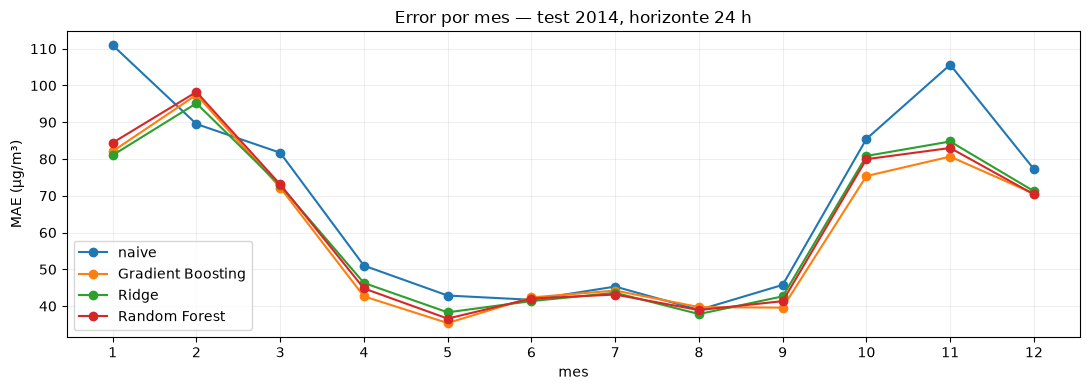

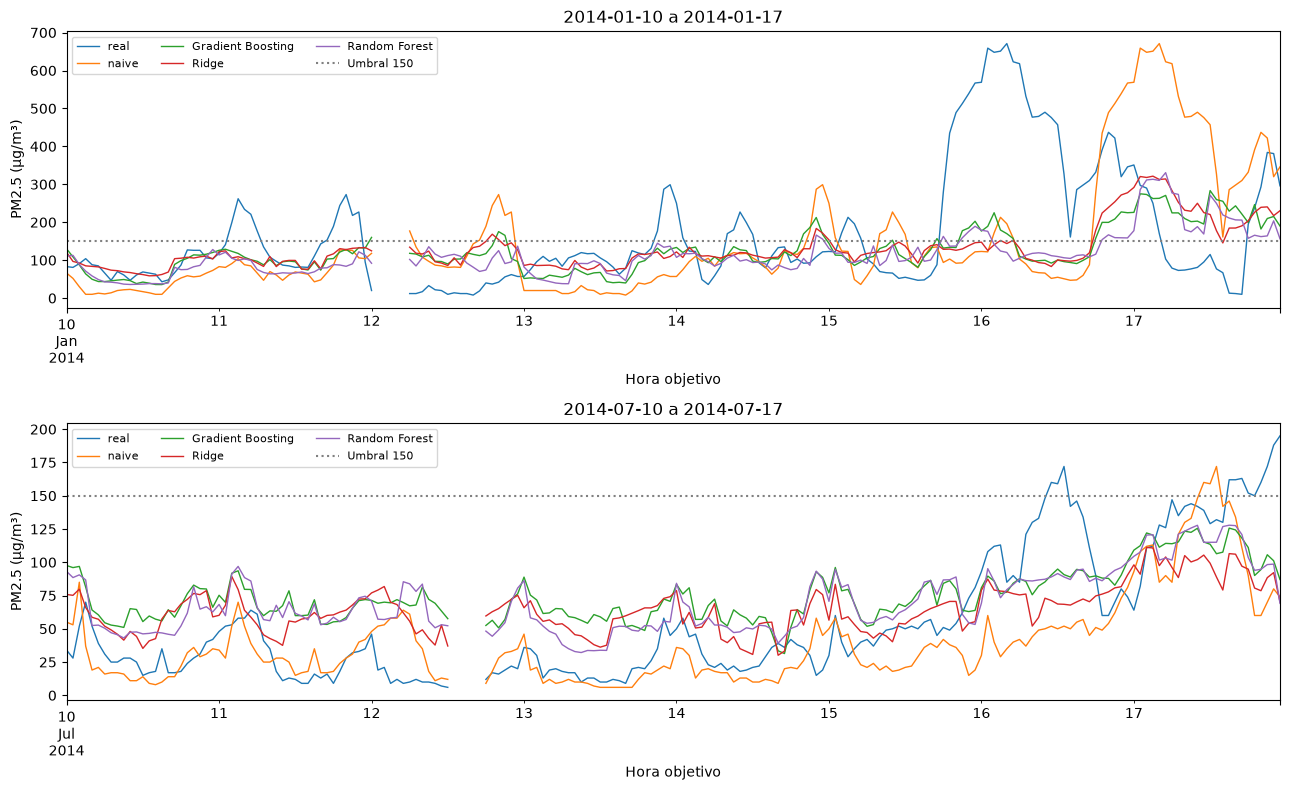

In [15]:
errores = predicciones.drop(columns='real').sub(y_test, axis=0).abs()
mae_mensual = errores.groupby(errores.index.month).mean()
mae_mensual.index.name = 'mes'
display(mae_mensual.round(2))

mae_mensual.plot(figsize=(11, 4), marker='o')
plt.ylabel('MAE (µg/m³)')
plt.title('Error por mes — test 2014, horizonte 24 h')
plt.xticks(range(1, 13))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, (inicio, fin) in zip(axes, [('2014-01-10', '2014-01-17'),
                                  ('2014-07-10', '2014-07-17')]):
    predicciones.loc[inicio:fin].asfreq('h').plot(ax=ax, linewidth=1)
    ax.axhline(UMBRAL, color='grey', linestyle=':', label='Umbral 150')
    ax.set_title(f'{inicio} a {fin}')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_xlabel('Hora objetivo')
    ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## 9. Resultados y límites

Se informa del modelo seleccionado en validación, aunque otro consiga mejor
resultado en test. Las métricas se calculan sin redondear; se redondean al mostrar.


In [16]:
global_ganador = metricas.loc[('global', ganador_validacion)]
alta_ganador = metricas.loc[(f'> {UMBRAL}', ganador_validacion)]
print('Elegido con 2013:', ganador_validacion)
print(f'Test: RMSE {global_ganador["RMSE"]:.2f}; MAE {global_ganador["MAE"]:.2f}')
print(f'Skill RMSE global: {global_ganador["skill_RMSE"]:.1%}')
print(f'Skill RMSE en horas > {UMBRAL}: {alta_ganador["skill_RMSE"]:.1%}')
print(f'Recall de horas altas: {alertas.loc[ganador_validacion, "recall"]:.1%}')


Elegido con 2013: Gradient Boosting
Test: RMSE 81.92; MAE 59.92
Skill RMSE global: 17.8%
Skill RMSE en horas > 150: -2.2%
Recall de horas altas: 34.8%


### Lectura de la ejecución guardada

La selección se realiza con RMSE medio en las tres rondas de 2013. El test de 2014 se informa por separado y no modifica las configuraciones.

La serie se completa para que `ForecasterRecursive` pueda generar retardos sobre un índice horario continuo. Los ejemplos afectados por imputaciones reciben peso 0 mediante `weight_func`, y los objetivos imputados se excluyen también de las métricas. Por tanto, el número de horas evaluadas puede diferir del cuaderno anterior.


- Se excluyen objetivos imputados de las métricas. En entrenamiento, los ejemplos
  con objetivo o lags imputados reciben peso cero. En predicción se permiten lags completados
  hacia delante; el resultado describe ese escenario de datos faltantes.
- No hay una marca de imputación meteorológica: la trazabilidad solo cubre PM2.5.
- Los tres modelos y persistencia se evalúan sobre las mismas horas. SARIMA histórico usa otras.
- La selección usa 2013; 2014 se reserva para informar. El análisis exploratorio previo ya vio 2014.
- Los lags son fijos y la búsqueda es pequeña. Mejor RMSE no implica mejor detección de picos.
- El lote es equivalente al paso 24 con estos lags; no generalizarlo a lags menores que 24.


In [17]:
salida = RAIZ / 'notebooks/resultados_ml_24h'
salida.mkdir(parents=True, exist_ok=True)
resultados_cv.to_csv(salida / 'validacion.csv', index=False)
mejores.to_csv(salida / 'configuraciones_elegidas.csv', index=False)
predicciones.to_csv(salida / 'predicciones_test.csv', index_label='datetime')
metricas.to_csv(salida / 'metricas_test.csv')
alertas.to_csv(salida / 'alertas_test.csv')
mae_mensual.to_csv(salida / 'mae_mensual.csv')
comparacion_baselines.to_csv(salida / 'comparacion_baselines_05_1.csv', index=False)
if EJECUTAR_PICOS:
    resumen_picos.to_csv(salida / 'optimizacion_episodios_altos.csv', index=False)
    resultado_picos_test.to_csv(salida / 'resultado_picos_test.csv', index=False)
print('Resultados guardados en:', salida)

print(f'Tiempo total: {perf_counter() - INICIO:.1f} s')


Resultados guardados en: ..\notebooks\resultados_ml_24h
Tiempo total: 93.3 s
